In [1]:

import multiprocessing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator


In [2]:
file_path3 = "csv-files/run3.csv"
data_run2 = pd.read_csv(file_path3, header=None)
spectrum_run2 = data_run2[0].values
t_run2 = 5151460 # 60 days exposure

Text(0, 0.5, 'Counts')

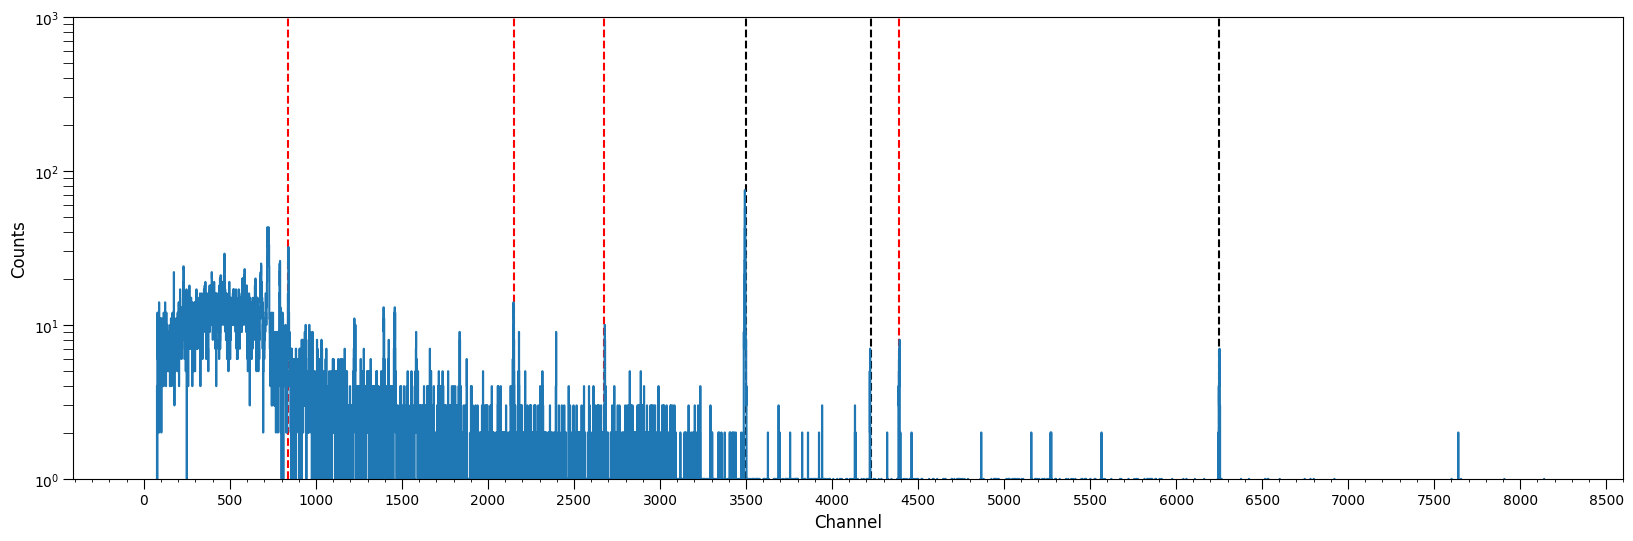

In [278]:
plt.figure(figsize=(20, 6))
ax = plt.gca()


dx_major = 500
dx_minor = 100


ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))
ax.yaxis.set_minor_locator(MultipleLocator(dy_minor))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=7)


channels = np.arange(len(spectrum_run2))

#plt.xlim(800, 1000)
plt.ylim(1, 1000)

#plt.vlines(7650, ymin=1, ymax=10000, color='red', linestyle='dashed')
plt.vlines(6250, ymin=1, ymax=10000, color='black', linestyle='dashed')
plt.vlines(4390, ymin=1, ymax=10000, color='red', linestyle='dashed')
plt.vlines(4225, ymin=1, ymax=10000, color='black', linestyle='dashed')
plt.vlines(3500, ymin=1, ymax=10000, color='black', linestyle='dashed')
plt.vlines(2675, ymin=1, ymax=10000, color='red', linestyle='dashed')
plt.vlines(2150, ymin=1, ymax=10000, color='red', linestyle='dashed')
#plt.vlines(2180, ymin=1, ymax=10000, color='green', linestyle='dashed')
#plt.vlines(1460, ymin=1, ymax=10000, color='red', linestyle='dashed')
#plt.vlines(1225, ymin=1, ymax=10000, color='red', linestyle='dashed')
plt.vlines(840, ymin=1, ymax=10000, color='red', linestyle='dashed')
plt.step(channels, spectrum_run2)
plt.yscale('log')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Counts', fontsize=12)

In [7]:
def quadratic(x, a, b, c):
    return c * x**2 + b * x + a

def linear(x, a, b):
    return a * x + b

In [304]:



E_kev = [ 351.9,   #214Bi
         794.947,
         911.204,
         1120.,  #214Bi
    1460.83,  # 3500 ---> 40K
    1764.4494,  #4400 ---> 214Bi --> stessa intensità altro picco 
    1847.21, #1900  #214Bi
    2614.533  ] #---> 208Tl

E_chn = [ 840 , 1875, 2180,  2680,  3490, 4225,4390, 6250]


E_kev = [351.9,   #214Bi
          911.204,
    1460.83,  # 3500 ---> 40
    1764.4494,  #4400 ---> 214Bi --> stessa intensità altro picco 
    2614.533  ] #---> 208Tl

E_chn = [ 840,2180, 3490, 4225, 6250]





In [305]:
def chi_square_func(exp, theo, err, popt):
    dof = len(exp)-len(popt)
    chi = np.sum(((exp-theo)/ err)**2 )
    chi_red = chi/dof
    return chi, chi_red

In [306]:
def gaussian_linear(x, A, mu, sigma, m, q):
    """
    Gaussiana + fondo lineare
    """
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + m * x + q


def fit_func(
    spectrum,
    center,
    dx=25,
    kev=False,
    energies=None,
    plot=True,
    ax=None
):

    center = int(round(center))

    if kev:

        mask = (energies > center - dx) & (energies < center + dx)

        x_data = np.asarray(energies[mask])
        y_data = np.asarray(spectrum[mask], dtype=float)

    else:

        x_data = np.arange(center - dx, center + dx + 1)

        y_data = np.asarray(
            spectrum[center - dx:center + dx + 1],
            dtype=float
        )

    # Evita problemi con zeri
    y_data[y_data < 0] = 0

    # Errori poissoniani
    err_counts = np.sqrt(np.maximum(y_data, 1))

    # --------------------------------------------------
    # Stima iniziale del fondo dai bordi della finestra
    # --------------------------------------------------

    nedge = min(5, len(x_data)//4)

    x_bg = np.concatenate([
        x_data[:nedge],
        x_data[-nedge:]
    ])

    y_bg = np.concatenate([
        y_data[:nedge],
        y_data[-nedge:]
    ])

    m0, q0 = np.polyfit(x_bg, y_bg, 1)

    background_center = m0 * center + q0

    A0 = max(y_data) - background_center

    if A0 <= 0:
        A0 = max(y_data)

    sigma0 = 2

    initial_guess = [
        A0,        # ampiezza
        center,    # centro
        sigma0,    # sigma
        m0,        # coeff angolare
        q0         # intercetta
    ]

    bounds = (
        [
            0,
            center - 10,
            0.3,
            -1000,
            -1e6
        ],
        [
            100 * max(y_data),
            center + 10,
            20,
            1000,
            1e6
        ]
    )

    popt, pcov = curve_fit(
        gaussian_linear,
        x_data,
        y_data,
        sigma=err_counts,
        absolute_sigma=True,
        p0=initial_guess,
        bounds=bounds,
        maxfev=20000
    )

    err = np.sqrt(np.diag(pcov))

    dof = len(x_data) - len(popt)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    if ax is None:
        ax = plt.gca()

    if plot:

        bins = np.linspace(
            x_data.min(),
            x_data.max(),
            len(x_data) + 1
        )

        counts, bin_edges, _ = ax.hist(
            x_data,
            bins=bins,
            weights=y_data,
            histtype='step',
            color='black',
            label='Data'
        )

        xfit = np.linspace(
            x_data.min(),
            x_data.max(),
            1000
        )

        yfit = gaussian_linear(xfit, *popt)

        ax.plot(
            xfit,
            yfit,
            lw=2,
            color='deepskyblue',
            label='Gaussian + linear bg'
        )

        ax.axvline(
            popt[1],
            color='deepskyblue',
            linestyle='--',
            lw=2,
            label=f'Peak = {popt[1]:.2f}'
        )

        ax.set_xlim(x_data.min(), x_data.max())

        if kev:

            ax.set_xlabel('E [keV]')
            ax.set_ylabel('Counts')

            ax.xaxis.set_major_locator(
                MultipleLocator(2)
            )

            ax.xaxis.set_minor_locator(
                MultipleLocator(1)
            )

            ax.set_title(
                f'Fit @ {center} keV'
            )

        else:

            ax.set_xlabel('Channel')
            ax.set_ylabel('Counts')

            ax.xaxis.set_major_locator(
                MultipleLocator(10)
            )

            ax.xaxis.set_minor_locator(
                MultipleLocator(1)
            )

            ax.set_title(
                f'Fit @ {center} ch'
            )

        ax.grid(alpha=0.3)
        ax.legend()

    return popt, err, dof

In [307]:

def gaussian_linear(x, A, mu, sigma, m, q):
    """
    Gaussiana + fondo lineare
    """
    return (
        A * np.exp(-(x - mu)**2 / (2 * sigma**2))
        + m * x + q
    )


def fit_func(
    spectrum,
    center,
    dx=25,
    plot=True,
    ax=None
):

    center = int(round(center))

    # -----------------------------
    # DATA (sempre CHANNELS)
    # -----------------------------
    x_data = np.arange(center - dx, center + dx + 1)
    y_data = np.asarray(
        spectrum[center - dx:center + dx + 1],
        dtype=float
    )

    # evita valori negativi
    y_data = np.clip(y_data, 0, None)

    # errore poissoniano stabile
    err_counts = np.sqrt(y_data + 1)

    # -----------------------------
    # BACKGROUND FIT (sidebands)
    # -----------------------------
    nedge = max(3, len(x_data) // 5)

    x_bg = np.concatenate([x_data[:nedge], x_data[-nedge:]])
    y_bg = np.concatenate([y_data[:nedge], y_data[-nedge:]])

    m0, q0 = np.polyfit(x_bg, y_bg, 1)

    # stima ampiezza
    background_center = m0 * center + q0
    A0 = max(y_data) - background_center
    if A0 < 0:
        A0 = max(y_data)

    sigma0 = 2.0

    initial_guess = [A0, center, sigma0, m0, q0]

    # -----------------------------
    # BOUNDS (coerenti con counts)
    # -----------------------------
    bounds = (
        [
            0,              # A
            center - dx,    # mu
            0.5,            # sigma
            -np.inf,        # m
            -np.inf         # q
        ],
        [
            10 * max(y_data) + 1,
            center + dx,
            20,
            np.inf,
            np.inf
        ]
    )

    # -----------------------------
    # FIT
    # -----------------------------
    popt, pcov = curve_fit(
        gaussian_linear,
        x_data,
        y_data,
        p0=initial_guess,
        sigma=err_counts,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=20000
    )

    err = np.sqrt(np.diag(pcov))
    dof = len(x_data) - len(popt)

    # -----------------------------
    # PLOT
    # -----------------------------
    if ax is None:
        ax = plt.gca()

    if plot:

        ax.step(x_data, y_data, where='mid', color='black', label='Data')

        xfit = np.linspace(x_data.min(), x_data.max(), 1000)
        yfit = gaussian_linear(xfit, *popt)

        ax.plot(xfit, yfit, color='deepskyblue', lw=2,
                label='Gaussian + linear bg')

        ax.axvline(
            popt[1],
            color='deepskyblue',
            linestyle='--',
            lw=2,
            label=f'Peak = {popt[1]:.2f} ch'
        )

        ax.set_xlim(x_data.min(), x_data.max())
        ax.set_xlabel('Channel')
        ax.set_ylabel('Counts')

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(MultipleLocator(1))

        ax.grid(alpha=0.3)
        ax.legend()
        ax.set_title(f'Fit @ {center} ch')

    return popt, err, dof

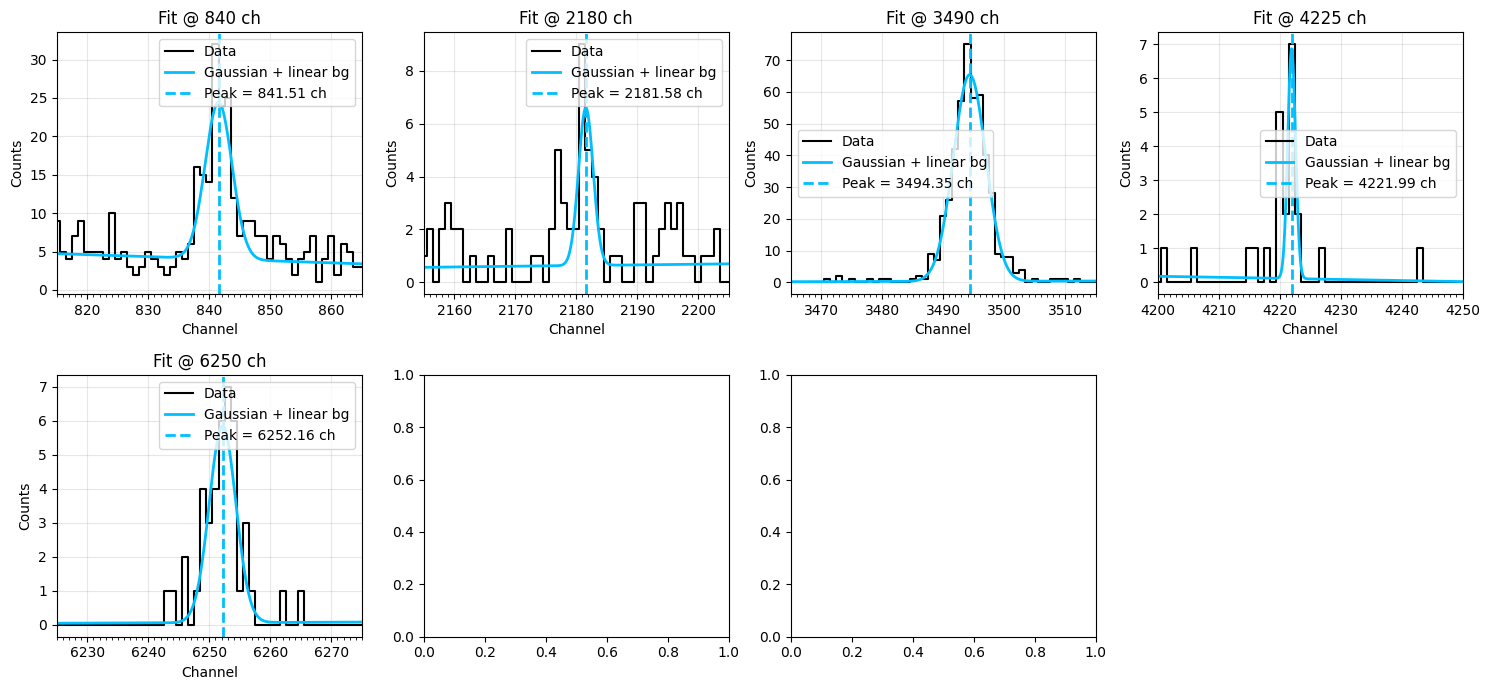

In [308]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()


popt_chn = []
popt_chn_err = []

for i, e in enumerate(E_chn):

    popt, err, dof = fit_func(
        spectrum_run2,
        e,
        dx=25,
        ax=axes[i]
    )

    popt_chn.append(popt[1])
    popt_chn_err.append(err[1])

# elimina l'ultimo subplot vuoto
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

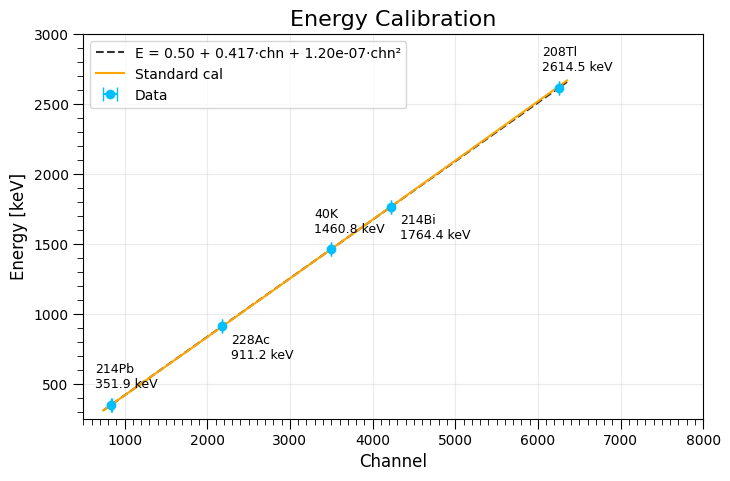

In [319]:

names = np.array([
    '228Ac',
    '228Ac',
    '228Ac',
    '228Ac',
    '40K',
    '214Bi',
    '208Tl'
])


names = np.array(
    [
        '214Pb',
        '228Ac',
    '40K',
    '214Bi',
    '208Tl'
])

plt.figure(figsize=(8, 5))
ax = plt.gca()

# -------------------
# ASSI
# -------------------
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.tick_params(axis='x', which='major', length=7, labelsize=10)
ax.tick_params(axis='x', which='minor', length=4, labelsize=0)

ax.yaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_minor_locator(MultipleLocator(100))
ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4, labelsize=0)

# -------------------
# DATI
# -------------------
plt.errorbar(
    popt_chn,
    E_kev,
    xerr=popt_chn_err,
    fmt='o',
    color='deepskyblue',
    capsize=5,
    label='Data'
)

# -------------------
# ETICHETTE PUNTI
# -------------------
offsets = [200, -150]
offx = [-200, 110]

for i, (x, y, name) in enumerate(zip(popt_chn, E_kev, names)):

    dy = offsets[i % 2]
    dx = offx[i % 2]

    plt.text(
        x + dx,
        y + dy,
        f"{name}\n{y:.1f} keV",
        fontsize=9,
        ha='left',
        va='center'
    )

# -------------------
# FIT QUADRATICO
# -------------------
def quadratic(x, a, b, c):
    return a + b*x + c*x**2

p0 = [100, 1, 0]
bounds = (
    [0, 0,  1e-7],
    [1000, 1, 1e-6])
popt, pcov = curve_fit(quadratic, popt_chn, E_kev, p0=p0)

x_fit = np.linspace(min(popt_chn)-100, max(popt_chn)+100, 500)
y_fit = quadratic(x_fit, *popt)

plt.plot(
    x_fit,
    y_fit,
    color='black',
    ls='--',
    alpha=0.8,
    label=(
        f"E = {popt[0]:.2f} + {popt[1]:.3f}·chn + "
        f"{popt[2]:.2e}·chn²"
    )
)

plt.plot(x_fit , 2.78 + 0.414 * x_fit + 8.7e-7 * x_fit**2, color='orange', label = 'Standard cal')
# -------------------
# LABELS
# -------------------
plt.xlabel('Channel', size=12)
plt.ylabel('Energy [keV]', size=12)
plt.title('Energy Calibration', size=16)
plt.xlim(500, 8000)
plt.ylim(250, 3000)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [310]:
popt

array([5.03999145e-01, 4.17351849e-01, 1.19722147e-07])

In [311]:
np.sqrt(np.diag(pcov))

array([7.37581885e-01, 4.69399796e-04, 6.40432041e-08])

In [312]:
quadratic(338, *popt)


np.float64(141.5826016709288)

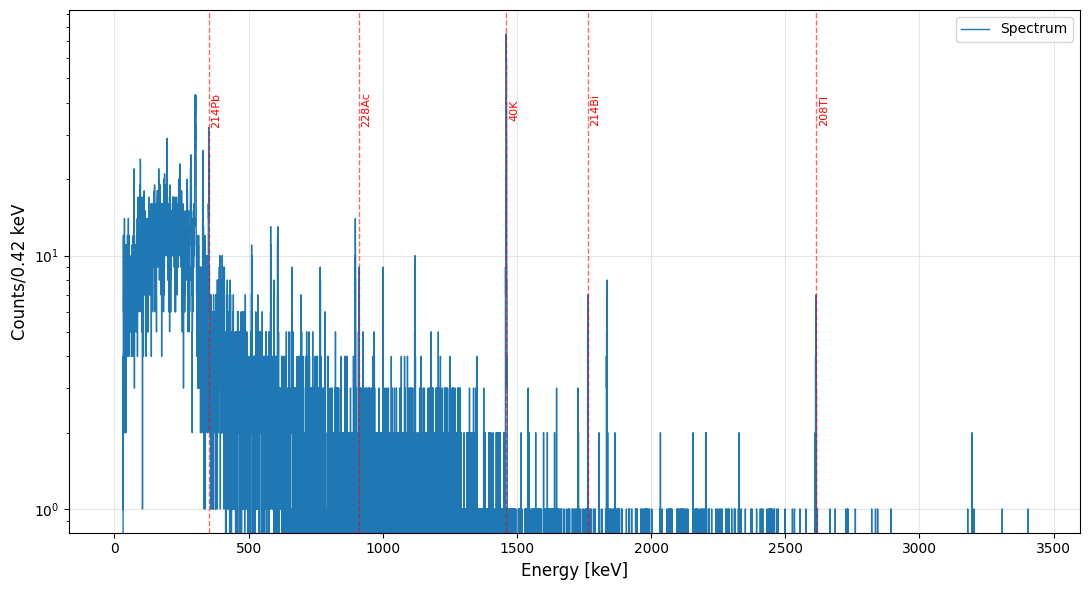

In [320]:
# -------------------
# CANALI → ENERGIA
# -------------------
channels = np.arange(len(spectrum_run2))
energy_axis = quadratic(channels, *popt)


# -------------------
# PLOT
# -------------------
plt.figure(figsize=(11, 6))
ax = plt.gca()

ax.step(
    energy_axis,
    spectrum_run2,
    #where='mid',
    lw=1,
    label='Spectrum'
)

ax.set_yscale('log')


# -------------------
# PICCHI DI CALIBRAZIONE
# (in energia, quindi E_kev)
# -------------------
for e, name in zip(E_kev, names):

    ax.axvline(
        e,
        color='red',
        linestyle='--',
        alpha=0.6,
        lw=1
    )

    ax.text(
        e + 10,
        max(spectrum_run2)*0.5,
        name,
        rotation=90,
        fontsize=8,
        color='red',
        va='center'
    )


# -------------------
# LABELS
# -------------------
ax.set_xlabel('Energy [keV]', fontsize=12)
ax.set_ylabel(f'Counts/{energy_axis[1]-energy_axis[0]:.2f} keV', fontsize=12)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

(0.0, 50.0)

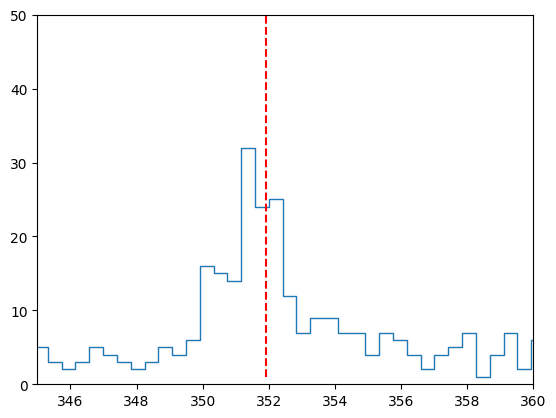

In [318]:
plt.step( energy_axis,
    spectrum_run2,
    #where='mid',
    lw=1,
    label='Spectrum'
)

plt.xlim(345, 360)
plt.vlines(1460.8, ymin=1, ymax=10, color='red', linestyle='dashed')
plt.vlines(2614.8, ymin=1, ymax=10, color='red', linestyle='dashed')
plt.vlines(351.9, ymin=1, ymax=50, color='red', linestyle='dashed')
plt.ylim(0,50)